In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
# data load
folder = '/Users/selina/Desktop/365mc_re/0.code/1_preprocessing'

train_x = pd.read_csv(f'{folder}/train_x.csv', encoding='utf-8-sig')
test_x = pd.read_csv(f'{folder}/test_x.csv', encoding='utf-8-sig')
train_y = pd.read_csv(f'{folder}/train_y.csv', encoding='utf-8-sig')
test_y = pd.read_csv(f'{folder}/test_y.csv', encoding='utf-8-sig')

def list

In [3]:
# RMSE score
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_score, greater_is_better=False)

# MAPE with zero handling
def mape_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = (y_true != 0) & (~np.isnan(y_true))  # 0과 NaN 값 제외
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [4]:
# 95% CI
def calculate_ci(data, confidence=0.95):
    data = np.array(data)
    mean = np.mean(data)
    n = len(data)
    sem = stats.sem(data)
    h = sem * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean, mean - h, mean + h

In [5]:
def regression_cv(model, X, y, cv=5, random_state=42, target_names=None):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    metrics = {
        'r2': [], 'mae': [], 'mape': [], 'rmse': [],
        'r2_target': [[] for _ in range(y.shape[1])],
        'mae_target': [[] for _ in range(y.shape[1])],
        'mape_target': [[] for _ in range(y.shape[1])],
        'rmse_target': [[] for _ in range(y.shape[1])]
    }
    feature_importances = []
    feature_names = X.columns if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X.shape[1])]
    
    if target_names is None:
        target_names = [f'Target_{i}' for i in range(y.shape[1])]
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        fold_r2, fold_mae, fold_mape, fold_rmse = [], [], [], []
        
        for i in range(y.shape[1]):
            y_val_i = y_val.iloc[:, i]
            y_pred_i = y_pred[:, i]
            
            r2_val = r2_score(y_val_i, y_pred_i)
            mae_val = mean_absolute_error(y_val_i, y_pred_i)
            mape_val = mape_score(y_val_i, y_pred_i)
            rmse_val = np.sqrt(mean_squared_error(y_val_i, y_pred_i))
            
            fold_r2.append(r2_val)
            fold_mae.append(mae_val)
            fold_mape.append(mape_val)
            fold_rmse.append(rmse_val)
            
            metrics['r2_target'][i].append(r2_val)
            metrics['mae_target'][i].append(mae_val)
            metrics['mape_target'][i].append(mape_val)
            metrics['rmse_target'][i].append(rmse_val)
        
        metrics['r2'].append(np.mean(fold_r2))
        metrics['mae'].append(np.mean(fold_mae))
        metrics['mape'].append(np.mean(fold_mape))
        metrics['rmse'].append(np.mean(fold_rmse))
        
        fold_imp = []
        if hasattr(model, 'feature_importances_'):
            fold_imp = model.feature_importances_
        elif hasattr(model, 'estimators_'):
            imps = [est.feature_importances_ for est in model.estimators_ 
                    if hasattr(est, 'feature_importances_')]
            if imps:
                fold_imp = np.mean(imps, axis=0)
        
        feature_importances.append(fold_imp)
        
        print(f"\nCV={fold}{'-'*75}")
        print(f"Mean Metrics: R²={np.mean(fold_r2):.4f}, MAE={np.mean(fold_mae):.4f}, "
              f"MAPE={np.mean(fold_mape):.4f}%, RMSE={np.mean(fold_rmse):.4f}")
        
        for i, name in enumerate(target_names):
            print(f"  {name}: R²={fold_r2[i]:.4f}, MAE={fold_mae[i]:.4f}, "
                  f"MAPE={fold_mape[i]:.4f}%, RMSE={fold_rmse[i]:.4f}")
    
    print("\n" + "="*80)
    print("SUMMARY WITH 95% CONFIDENCE INTERVALS")
    print("="*80)
    
    for metric in ['r2', 'mae', 'mape', 'rmse']:
        mean, lower, upper = calculate_ci(metrics[metric])
        print(f"Mean {metric.upper()}: {mean:.4f} (95% CI: {lower:.4f}-{upper:.4f})")
    
    print("\nPER-TARGET METRICS:")
    for i, name in enumerate(target_names):
        print(f"\n{name}:")
        for metric in ['r2', 'mae', 'mape', 'rmse']:
            values = metrics[f'{metric}_target'][i]
            mean, lower, upper = calculate_ci(values)
            print(f"  {metric.upper()}: {mean:.4f} (95% CI: {lower:.4f}-{upper:.4f})")
    
    return metrics, feature_importances

Hyperparameter tuning

Tree-based

In [6]:
# for GridSearch
rmse_scorer = make_scorer(rmse_score, greater_is_better=False)

In [ ]:
# DecisionTreeRegressor
# dt_params = {
#     'max_depth': [None, 5, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# dt = DecisionTreeRegressor(random_state=42)
# dt_multi = MultiOutputRegressor(dt)
# dt_grid = GridSearchCV(dt_multi, param_grid={'estimator__' + k: v for k, v in dt_params.items()},
#                        scoring=rmse_scorer, n_jobs=-1, cv=5, verbose=1)
# dt_grid.fit(train_x, train_y)
# print('Best Params:', dt_grid.best_params_)
# print('Best RMSE:', -dt_grid.best_score_)
# dt_best = dt_grid.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Params: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 4, 'estimator__min_samples_split': 10}
Best RMSE: 2.464689688967399


In [7]:
# RandomForestRegressor
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestRegressor(random_state=42)
rf_multi = MultiOutputRegressor(rf)
rf_grid = GridSearchCV(rf_multi, param_grid={'estimator__' + k: v for k, v in rf_params.items()},
                       scoring=rmse_scorer, n_jobs=-1, cv=5, verbose=1)
rf_grid.fit(train_x, train_y)
print('Best Params:', rf_grid.best_params_)
print('Best RMSE:', -rf_grid.best_score_)
rf_best = rf_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Params: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 100}
Best RMSE: 2.1167666681169957


In [8]:
# ExtraTreesRegressor
et_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
et = ExtraTreesRegressor(random_state=42)
et_multi = MultiOutputRegressor(et)
et_grid = GridSearchCV(et_multi, param_grid={'estimator__' + k: v for k, v in et_params.items()},
                       scoring=rmse_scorer, n_jobs=-1, cv=5, verbose=1)
et_grid.fit(train_x, train_y)
print('Best Params:', et_grid.best_params_)
print('Best RMSE:', -et_grid.best_score_)
et_best = et_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 100}
Best RMSE: 1.9863297767779435


Cross-validation

Tree-based

In [9]:
target_names = train_y.columns.tolist()  # target columns

In [ ]:
# DecisionTreeRegressor
# print("\n" + "="*80)
# print("# DECISION TREE REGRESSOR - DETAILED CV")
# print("="*80)
# dt_metrics, dt_importances = regression_cv(dt_best, train_x, train_y, 
#                                           target_names=target_names)


# DECISION TREE REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9734, MAE=1.5087, MAPE=2.6876%, RMSE=2.7160
  af_weight: R²=0.9633, MAE=1.4913, MAPE=2.3996%, RMSE=2.2060
  af_size: R²=0.9836, MAE=1.5262, MAPE=2.9756%, RMSE=3.2261

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9767, MAE=1.5095, MAPE=2.6606%, RMSE=2.2462
  af_weight: R²=0.9614, MAE=1.5516, MAPE=2.4973%, RMSE=2.1782
  af_size: R²=0.9920, MAE=1.4675, MAPE=2.8240%, RMSE=2.3141

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9748, MAE=1.4461, MAPE=2.5543%, RMSE=2.3146
  af_weight: R²=0.9577, MAE=1.5007, MAPE=2.3863%, RMSE=2.3470
  af_size: R²=0.9920, MAE=1.3916, MAPE=2.7223%, RMSE=2.2821

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9712, MAE=1.5939, MAPE=2.7615%, RMSE=2.6014
  af_weight: R²=0

In [10]:
# RandomForestRegressor
print("\n" + "="*80)
print("# RANDOM FOREST REGRESSOR - DETAILED CV")
print("="*80)
rf_metrics, rf_importances = regression_cv(rf_best, train_x, train_y, 
                                          target_names=target_names)


# RANDOM FOREST REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9819, MAE=1.1880, MAPE=2.1209%, RMSE=2.3463
  af_weight: R²=0.9777, MAE=1.1496, MAPE=1.8507%, RMSE=1.7200
  af_size: R²=0.9861, MAE=1.2265, MAPE=2.3910%, RMSE=2.9726

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9856, MAE=1.1920, MAPE=2.0990%, RMSE=1.8256
  af_weight: R²=0.9770, MAE=1.1722, MAPE=1.8909%, RMSE=1.6818
  af_size: R²=0.9942, MAE=1.2118, MAPE=2.3070%, RMSE=1.9695

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9814, MAE=1.1710, MAPE=2.0720%, RMSE=2.0212
  af_weight: R²=0.9693, MAE=1.1735, MAPE=1.8667%, RMSE=2.0004
  af_size: R²=0.9936, MAE=1.1686, MAPE=2.2772%, RMSE=2.0420

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9800, MAE=1.2221, MAPE=2.1352%, RMSE=2.1910
  af_weight: R²=0

In [11]:
# ExtraTreesRegressor
print("\n" + "="*80)
print("# EXTRA TREES REGRESSOR - DETAILED CV")
print("="*80)
et_metrics, et_importances = regression_cv(et_best, train_x, train_y, 
                                          target_names=target_names)


# EXTRA TREES REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9842, MAE=1.0485, MAPE=1.8825%, RMSE=2.2224
  af_weight: R²=0.9813, MAE=0.9606, MAPE=1.5554%, RMSE=1.5755
  af_size: R²=0.9870, MAE=1.1364, MAPE=2.2096%, RMSE=2.8693

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9870, MAE=1.0657, MAPE=1.8800%, RMSE=1.7720
  af_weight: R²=0.9799, MAE=0.9850, MAPE=1.5862%, RMSE=1.5726
  af_size: R²=0.9942, MAE=1.1463, MAPE=2.1738%, RMSE=1.9713

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9847, MAE=1.0363, MAPE=1.8246%, RMSE=1.8316
  af_weight: R²=0.9748, MAE=1.0218, MAPE=1.6342%, RMSE=1.8132
  af_size: R²=0.9947, MAE=1.0508, MAPE=2.0150%, RMSE=1.8501

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9836, MAE=1.0735, MAPE=1.8894%, RMSE=2.0409
  af_weight: R²=0.9

Hyperparameter tuning

Gradient Boosting

In [12]:
# GradientBoostingRegressor
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
gb = GradientBoostingRegressor(random_state=42)
gb_multi = MultiOutputRegressor(gb)
gb_grid = GridSearchCV(gb_multi, param_grid={'estimator__' + k: v for k, v in gb_params.items()},
                       scoring=rmse_scorer, n_jobs=-1, cv=5, verbose=1)
gb_grid.fit(train_x, train_y)
print('Best Params:', gb_grid.best_params_)
print('Best RMSE:', -gb_grid.best_score_)
gb_best = gb_grid.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 5, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 200}
Best RMSE: 2.11042320622899


In [13]:
# REVISION R1: HGBR
# Histogram-basedGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
hgb_params = {
    'max_iter': [100, 200],             
    'max_leaf_nodes': [15, 31, 63],      
    'learning_rate': [0.01, 0.1],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0]
}

hgb = HistGradientBoostingRegressor(random_state=42)
hgb_multi = MultiOutputRegressor(hgb)
hgb_grid = GridSearchCV(
    hgb_multi,
    param_grid={'estimator__' + k: v for k, v in hgb_params.items()},scoring=rmse_scorer,
    n_jobs=-1, cv=5, verbose=1
)

hgb_grid.fit(train_x, train_y)
print('Best Params:', hgb_grid.best_params_)
print('Best RMSE:', -hgb_grid.best_score_)
hgb_best = hgb_grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'estimator__l2_regularization': 1.0, 'estimator__learning_rate': 0.1, 'estimator__max_iter': 200, 'estimator__max_leaf_nodes': 63, 'estimator__min_samples_leaf': 20}
Best RMSE: 2.1080801187930986


In [ ]:
# CatBoost (Native multi-output support)
# cb_params = {
#     'iterations': [100, 200],
#     'depth': [4, 6, 8],
#     'learning_rate': [0.01, 0.1],
#     'l2_leaf_reg': [1, 3, 5]
# }
# cb = CatBoostRegressor(
#     loss_function='MultiRMSE',  # Native multi-output
#     random_seed=42,
#     verbose=False,
#     allow_writing_files=False   # directory error
# )
# cb_grid = GridSearchCV(cb, param_grid=cb_params,
#                         scoring=rmse_scorer, n_jobs=-1, cv=5, verbose=1)
# cb_grid.fit(train_x, train_y)
# print('CatBoost Best Params:', cb_grid.best_params_)
# print('CatBoost Best RMSE:', -cb_grid.best_score_)
# cb_best = cb_grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
CatBoost Best Params: {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
CatBoost Best RMSE: 2.252854174348665


In [ ]:
# XGBoost (Use wrapper)
# xgb_params = {
#     'n_estimators': [100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }
# xgb = XGBRegressor(random_state=42)
# xgb_multi = MultiOutputRegressor(xgb)
# xgb_grid = GridSearchCV(xgb_multi, param_grid={'estimator__' + k: v for k, v in xgb_params.items()},
#                         scoring=rmse_scorer, n_jobs=-1, cv=5, verbose=1)
# xgb_grid.fit(train_x, train_y)
# print('XGBoost Best Params:', xgb_grid.best_params_)
# print('XGBoost Best RMSE:', -xgb_grid.best_score_)
# xgb_best = xgb_grid.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
XGBoost Best Params: {'estimator__colsample_bytree': 0.8, 'estimator__learning_rate': 0.1, 'estimator__max_depth': 7, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}
XGBoost Best RMSE: 2.049491446329572


Cross-valdation

Gradient Boosting

In [14]:
target_names = train_y.columns.tolist()

In [15]:
# GradientBoosting
print("\n" + "="*80)
print("# GRADIENT BOOSTING REGRESSOR - DETAILED CV")
print("="*80)
gb_metrics, gb_importances = regression_cv(gb_best, train_x, train_y, 
                                          target_names=target_names)


# GRADIENT BOOSTING REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9806, MAE=1.2838, MAPE=2.2952%, RMSE=2.3860
  af_weight: R²=0.9749, MAE=1.2997, MAPE=2.1163%, RMSE=1.8233
  af_size: R²=0.9863, MAE=1.2679, MAPE=2.4740%, RMSE=2.9486

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9843, MAE=1.2932, MAPE=2.2862%, RMSE=1.8284
  af_weight: R²=0.9737, MAE=1.3208, MAPE=2.1439%, RMSE=1.7975
  af_size: R²=0.9948, MAE=1.2656, MAPE=2.4284%, RMSE=1.8592

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9818, MAE=1.2785, MAPE=2.2943%, RMSE=2.0064
  af_weight: R²=0.9701, MAE=1.3013, MAPE=2.1027%, RMSE=1.9752
  af_size: R²=0.9936, MAE=1.2557, MAPE=2.4858%, RMSE=2.0376

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9810, MAE=1.3026, MAPE=2.3067%, RMSE=2.1605
  af_weight: 

In [16]:
# Revision R1: HGBR
# Histogram-basedGradientBoosting
print("\n" + "="*80)
print("# Histogram-based GRADIENT BOOSTING REGRESSOR - DETAILED CV")
print("="*80)
hgb_metrics, hgb_importances = regression_cv(hgb_best, train_x, train_y, 
                                          target_names=target_names)


# Histogram-based GRADIENT BOOSTING REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9812, MAE=1.2255, MAPE=2.1917%, RMSE=2.3712
  af_weight: R²=0.9763, MAE=1.2060, MAPE=1.9461%, RMSE=1.7718
  af_size: R²=0.9861, MAE=1.2450, MAPE=2.4374%, RMSE=2.9707

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9846, MAE=1.2605, MAPE=2.2215%, RMSE=1.8474
  af_weight: R²=0.9749, MAE=1.2289, MAPE=1.9930%, RMSE=1.7569
  af_size: R²=0.9944, MAE=1.2922, MAPE=2.4500%, RMSE=1.9378

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9829, MAE=1.2112, MAPE=2.1462%, RMSE=1.9130
  af_weight: R²=0.9714, MAE=1.2375, MAPE=1.9890%, RMSE=1.9289
  af_size: R²=0.9945, MAE=1.1849, MAPE=2.3034%, RMSE=1.8971

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9808, MAE=1.2674, MAPE=2.2465%, RMSE=2.15

In [ ]:
# CatBoost
# print("\n" + "="*80)
# print("# CATBOOST REGRESSOR - DETAILED CV")
# print("="*80)
# cb_metrics, cb_importances = regression_cv(cb_best, train_x, train_y, 
#                                             target_names=target_names)


# CATBOOST REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9751, MAE=1.4498, MAPE=2.6156%, RMSE=2.5434
  af_weight: R²=0.9632, MAE=1.4723, MAPE=2.3803%, RMSE=2.2077
  af_size: R²=0.9869, MAE=1.4273, MAPE=2.8509%, RMSE=2.8792

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9788, MAE=1.4767, MAPE=2.5888%, RMSE=2.0597
  af_weight: R²=0.9637, MAE=1.5491, MAPE=2.4960%, RMSE=2.1140
  af_size: R²=0.9940, MAE=1.4044, MAPE=2.6815%, RMSE=2.0054

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9793, MAE=1.4006, MAPE=2.4977%, RMSE=2.0931
  af_weight: R²=0.9651, MAE=1.4708, MAPE=2.3770%, RMSE=2.1310
  af_size: R²=0.9935, MAE=1.3304, MAPE=2.6185%, RMSE=2.0553

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9778, MAE=1.4319, MAPE=2.5217%, RMSE=2.2965
  af_weight: R²=0.9649

In [ ]:
# XGBoost
# print("\n" + "="*80)
# print("# XGBOOST REGRESSOR - DETAILED CV")
# print("="*80)
# xgb_metrics, xgb_importances = regression_cv(xgb_best, train_x, train_y, 
#                                             target_names=target_names)


# XGBOOST REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9827, MAE=1.1983, MAPE=2.1577%, RMSE=2.2462
  af_weight: R²=0.9773, MAE=1.1526, MAPE=1.8822%, RMSE=1.7348
  af_size: R²=0.9880, MAE=1.2440, MAPE=2.4333%, RMSE=2.7577

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9861, MAE=1.2079, MAPE=2.1380%, RMSE=1.7771
  af_weight: R²=0.9775, MAE=1.1718, MAPE=1.8988%, RMSE=1.6655
  af_size: R²=0.9947, MAE=1.2440, MAPE=2.3773%, RMSE=1.8886

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9838, MAE=1.1671, MAPE=2.0795%, RMSE=1.8751
  af_weight: R²=0.9730, MAE=1.1725, MAPE=1.8903%, RMSE=1.8760
  af_size: R²=0.9946, MAE=1.1617, MAPE=2.2687%, RMSE=1.8742

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9822, MAE=1.2239, MAPE=2.1583%, RMSE=2.1289
  af_weight: R²=0.9732,

Hyperparameter tuning

Other regressors

In [18]:
rmse_scorer = make_scorer(rmse_score, greater_is_better=False)

In [19]:
# AdaBoost Regressor
print("\n" + "="*80)
print("# ADABOOST REGRESSOR")
print("="*80)

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator': [  # base_estimator -> estimator 
        DecisionTreeRegressor(max_depth=1, random_state=42),
        DecisionTreeRegressor(max_depth=2, random_state=42),
        DecisionTreeRegressor(max_depth=3, random_state=42)
    ]
}

ada = AdaBoostRegressor(random_state=42)
ada_multi = MultiOutputRegressor(ada)

ada_param_grid = {
    'estimator__' + k: v for k, v in ada_params.items()
    if k != 'estimator'  # estimator는 별도
}
ada_param_grid['estimator__estimator'] = ada_params['estimator']  # estimator 직접 할당

ada_grid = GridSearchCV(
    ada_multi, 
    param_grid=ada_param_grid,
    scoring=rmse_scorer, 
    n_jobs=-1, 
    cv=5, 
    verbose=1
)
ada_grid.fit(train_x, train_y)
print('AdaBoost Best Params:', ada_grid.best_params_)
print('AdaBoost Best RMSE:', -ada_grid.best_score_)
ada_best = ada_grid.best_estimator_


# ADABOOST REGRESSOR
Fitting 5 folds for each of 27 candidates, totalling 135 fits
AdaBoost Best Params: {'estimator__estimator': DecisionTreeRegressor(max_depth=3, random_state=42), 'estimator__learning_rate': 0.01, 'estimator__n_estimators': 200}
AdaBoost Best RMSE: 3.0963766895227387


In [20]:
# Support Vector Regressor
print("\n" + "="*80)
print("# SUPPORT VECTOR REGRESSOR (OPTIMIZED)")
print("="*80)

# 속도 개선을 위해 파라미터 범위 축소
svr_params = {
    'kernel': ['rbf'],  # 가장 효율적인 커널 선택
    'C': [0.1, 1, 10],  # 값 범위 축소
    'epsilon': [0.1],    # 고정 값 사용
    'gamma': ['scale']   # 기본값 사용
}

svr = SVR()
svr_multi = MultiOutputRegressor(svr)
svr_param_grid = {'estimator__' + k: v for k, v in svr_params.items()}

svr_grid = GridSearchCV(
    svr_multi, 
    param_grid=svr_param_grid,
    scoring=rmse_scorer, 
    n_jobs=-1, 
    cv=5, 
    verbose=1
)
svr_grid.fit(train_x, train_y)
print('SVR Best Params:', svr_grid.best_params_)
print('SVR Best RMSE:', -svr_grid.best_score_)
svr_best = svr_grid.best_estimator_


# SUPPORT VECTOR REGRESSOR (OPTIMIZED)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
SVR Best Params: {'estimator__C': 10, 'estimator__epsilon': 0.1, 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}
SVR Best RMSE: 2.558671824758003


Cross-valdation

Other regressors

In [21]:
# AdaBoost Regressor
print("\n" + "="*80)
print("# ADABOOST REGRESSOR - DETAILED CV")
print("="*80)
ada_metrics, ada_importances = regression_cv(ada_best, train_x, train_y, 
                                            target_names=target_names)


# ADABOOST REGRESSOR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9597, MAE=2.2293, MAPE=4.2225%, RMSE=3.4047
  af_weight: R²=0.9466, MAE=1.8800, MAPE=3.1037%, RMSE=2.6596
  af_size: R²=0.9729, MAE=2.5786, MAPE=5.3413%, RMSE=4.1499

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9617, MAE=2.1821, MAPE=3.8949%, RMSE=3.0005
  af_weight: R²=0.9395, MAE=1.9737, MAPE=3.2634%, RMSE=2.7284
  af_size: R²=0.9840, MAE=2.3906, MAPE=4.5264%, RMSE=3.2726

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9631, MAE=2.1161, MAPE=3.8523%, RMSE=2.9974
  af_weight: R²=0.9426, MAE=1.9893, MAPE=3.2531%, RMSE=2.7357
  af_size: R²=0.9836, MAE=2.2429, MAPE=4.4516%, RMSE=3.2592

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9619, MAE=2.1358, MAPE=3.8474%, RMSE=3.0679
  af_weight: R²=0.9414

In [22]:
# Support Vector Regressor
print("\n" + "="*80)
print("# SVR - DETAILED CV")
print("="*80)
svr_metrics, svr_importances = regression_cv(svr_best, train_x, train_y, 
                                            target_names=target_names)


# SVR - DETAILED CV

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9692, MAE=1.5327, MAPE=2.7274%, RMSE=2.8986
  af_weight: R²=0.9567, MAE=1.5179, MAPE=2.4270%, RMSE=2.3960
  af_size: R²=0.9818, MAE=1.5475, MAPE=3.0279%, RMSE=3.4012

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9723, MAE=1.5353, MAPE=2.6557%, RMSE=2.3569
  af_weight: R²=0.9525, MAE=1.6109, MAPE=2.5721%, RMSE=2.4184
  af_size: R²=0.9921, MAE=1.4597, MAPE=2.7392%, RMSE=2.2954

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9740, MAE=1.4782, MAPE=2.6135%, RMSE=2.5231
  af_weight: R²=0.9596, MAE=1.4869, MAPE=2.3784%, RMSE=2.2937
  af_size: R²=0.9883, MAE=1.4695, MAPE=2.8486%, RMSE=2.7525

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9726, MAE=1.5063, MAPE=2.5958%, RMSE=2.5932
  af_weight: R²=0.9576, MAE=1.5241, M

CV table for single model

In [23]:
# 95% CI
def calculate_ci(data, confidence=0.95):
    data = np.array(data)
    mean = np.mean(data)
    n = len(data)
    if n < 2:
        return mean, mean, mean
    sem = stats.sem(data)
    h = sem * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean, mean - h, mean + h

In [24]:
single_metrics = []

# Decision Tree
# if 'dt_metrics' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(dt_metrics['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(dt_metrics['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(dt_metrics['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(dt_metrics['rmse'])
#     single_metrics.append(['DecisionTree', r2_mean, r2_lower, r2_upper, 
#                           mae_mean, mae_lower, mae_upper,
#                           mape_mean, mape_lower, mape_upper,
#                           rmse_mean, rmse_lower, rmse_upper])

# Random Forest
if 'rf_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(rf_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(rf_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(rf_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(rf_metrics['rmse'])
    single_metrics.append(['RandomForest', r2_mean, r2_lower, r2_upper, 
                          mae_mean, mae_lower, mae_upper,
                          mape_mean, mape_lower, mape_upper,
                          rmse_mean, rmse_lower, rmse_upper])

# Extra Trees
if 'et_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(et_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(et_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(et_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(et_metrics['rmse'])
    single_metrics.append(['ExtraTrees', r2_mean, r2_lower, r2_upper, 
                          mae_mean, mae_lower, mae_upper,
                          mape_mean, mape_lower, mape_upper,
                          rmse_mean, rmse_lower, rmse_upper])

# GradientBoosting
if 'gb_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(gb_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(gb_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(gb_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(gb_metrics['rmse'])
    single_metrics.append(['GradientBoosting', r2_mean, r2_lower, r2_upper, 
                          mae_mean, mae_lower, mae_upper,
                          mape_mean, mape_lower, mape_upper,
                          rmse_mean, rmse_lower, rmse_upper])
    
# REVISION R1
# Histogram-basedGradientBoosting
if 'hgb_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(gb_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(gb_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(gb_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(gb_metrics['rmse'])
    single_metrics.append(['HGradientBoosting', r2_mean, r2_lower, r2_upper, 
                          mae_mean, mae_lower, mae_upper,
                          mape_mean, mape_lower, mape_upper,
                          rmse_mean, rmse_lower, rmse_upper])

# AdaBoost
if 'ada_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(ada_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(ada_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(ada_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(ada_metrics['rmse'])
    single_metrics.append(['AdaBoost', r2_mean, r2_lower, r2_upper, 
                          mae_mean, mae_lower, mae_upper,
                          mape_mean, mape_lower, mape_upper,
                          rmse_mean, rmse_lower, rmse_upper])
# CatBoost
# if 'cb_metrics' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(ada_metrics['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(ada_metrics['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(ada_metrics['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(ada_metrics['rmse'])
#     single_metrics.append(['CatBoost', r2_mean, r2_lower, r2_upper, 
#                           mae_mean, mae_lower, mae_upper,
#                           mape_mean, mape_lower, mape_upper,
#                           rmse_mean, rmse_lower, rmse_upper])
# XGBoost
# if 'xgb_metrics' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(ada_metrics['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(ada_metrics['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(ada_metrics['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(ada_metrics['rmse'])
#     single_metrics.append(['XGBoost', r2_mean, r2_lower, r2_upper, 
#                           mae_mean, mae_lower, mae_upper,
#                           mape_mean, mape_lower, mape_upper,
#                           rmse_mean, rmse_lower, rmse_upper])

# SVR
if 'svr_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(svr_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(svr_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(svr_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(svr_metrics['rmse'])
    single_metrics.append(['SVR', r2_mean, r2_lower, r2_upper, 
                          mae_mean, mae_lower, mae_upper,
                          mape_mean, mape_lower, mape_upper,
                          rmse_mean, rmse_lower, rmse_upper])

all_metrics = single_metrics

In [25]:
# sorting
all_metrics_sorted = sorted(
    all_metrics,
    key=lambda x: (-x[1], x[10], x[4], x[7])  # x[1]=R², x[10]=RMSE, x[4]=MAE, x[7]=MAPE
)
# table
print("\n" + "="*135)
print("FINAL ALL MODELS RANKING (4 Metrics with 95% Confidence Intervals)")
print("="*135)
print(f"{'Rank':<5} | {'Model':<25} | {'R² (95% CI)':<25} | {'RMSE (95% CI)':<25} | {'MAE (95% CI)':<25} | {'MAPE (95% CI)':<25}")
print("-"*150)

for rank, (model, r2, r2_l, r2_u, mae, mae_l, mae_u, mape, mape_l, mape_u, rmse, rmse_l, rmse_u) in enumerate(all_metrics_sorted, 1):
    r2_str = f"{r2:.4f} ({r2_l:.4f}-{r2_u:.4f})"
    rmse_str = f"{rmse:.4f} ({rmse_l:.4f}-{rmse_u:.4f})"
    mae_str = f"{mae:.4f} ({mae_l:.4f}-{mae_u:.4f})"
    mape_str = f"{mape:.4f} ({mape_l:.4f}-{mape_u:.4f})"
    
    print(f"{rank:<5} | {model:<25} | {r2_str:<25} | {rmse_str:<25} | {mae_str:<25} | {mape_str:<25}")


FINAL ALL MODELS RANKING (4 Metrics with 95% Confidence Intervals)
Rank  | Model                     | R² (95% CI)               | RMSE (95% CI)             | MAE (95% CI)              | MAPE (95% CI)            
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | ExtraTrees                | 0.9854 (0.9832-0.9876)    | 1.9298 (1.6860-2.1737)    | 1.0466 (1.0147-1.0784)    | 1.8492 (1.7851-1.9133)   
2     | RandomForest              | 0.9826 (0.9798-0.9854)    | 2.0804 (1.8358-2.3250)    | 1.1877 (1.1600-1.2153)    | 2.0967 (2.0558-2.1375)   
3     | GradientBoosting          | 0.9825 (0.9802-0.9848)    | 2.0720 (1.8095-2.3345)    | 1.2845 (1.2664-1.3025)    | 2.2805 (2.2379-2.3232)   
4     | HGradientBoosting         | 0.9825 (0.9802-0.9848)    | 2.0720 (1.8095-2.3345)    | 1.2845 (1.2664-1.3025)    | 2.2805 (2.2379-2.3232)   
5     | SVR                       | 0.9733 (0.9691-

In [26]:
# save
import os
save_dir = r"/Users/selina/Desktop/365mc_re/0.code/2_modeling"
save_path = os.path.join(save_dir, "single_cv_result.csv")

In [27]:
lines = []
lines.append("Rank,Model,R² (95% CI),RMSE (95% CI),MAE (95% CI),MAPE (95% CI)")

for rank, (model, r2, r2_l, r2_u, mae, mae_l, mae_u, mape, mape_l, mape_u, rmse, rmse_l, rmse_u) in enumerate(all_metrics_sorted, 1):
    r2_str = f"{r2:.4f} ({r2_l:.4f}-{r2_u:.4f})"
    rmse_str = f"{rmse:.4f} ({rmse_l:.4f}-{rmse_u:.4f})"
    mae_str = f"{mae:.4f} ({mae_l:.4f}-{mae_u:.4f})"
    mape_str = f"{mape:.4f} ({mape_l:.4f}-{mape_u:.4f})"
    
    line = f"{rank},{model},{r2_str},{rmse_str},{mae_str},{mape_str}"
    lines.append(line)

with open(save_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"\n 저장 완료: {save_path}")


 저장 완료: /Users/selina/Desktop/365mc_re/0.code/2_modeling/single_cv_result.csv


Esemble model

Voting regressors

In [28]:
# check
train_y.columns
# et_best.estimators_[0]  # → af_weight 예측용 모델
# et_best.estimators_[1]  # → af_size 예측용 모델

Index(['af_weight', 'af_size'], dtype='object')

In [30]:
from sklearn.ensemble import VotingRegressor
from sklearn.base import RegressorMixin, BaseEstimator
import numpy as np

In [31]:
def run_voting_combo(model_dict, combo, train_x, train_y, target_names, verbose=True):
    name = "+".join(combo)
    if not all(model in model_dict for model in combo):
        print(f"[SKIP] {name} 조합은 일부 모델이 없음.")
        return None, None

    if verbose:
        print("\n" + "="*60)
        print(f"# VOTING: {' + '.join(combo).upper()}")
        print("="*60)

    # VotingRegressor for each target column
    voting_models = []
    for i in range(train_y.shape[1]):
        vr = VotingRegressor([
            (abbr, model_dict[abbr].estimators_[i]) for abbr in combo
        ])
        voting_models.append(vr)

    # Multi-output wrapper class
    class CustomMultiOutputVoting(RegressorMixin, BaseEstimator):
        def __init__(self, estimators):
            self.estimators = estimators

        def fit(self, X, y):
            for i, model in enumerate(self.estimators):
                model.fit(X, y.iloc[:, i])
            return self

        def predict(self, X):
            return np.column_stack([
                model.predict(X) for model in self.estimators
            ])

    # Wrap and fit the model
    final_model = CustomMultiOutputVoting(voting_models)
    final_model.fit(train_x, train_y)  
    # Cross-validation 
    metrics, _ = regression_cv(final_model, train_x, train_y, target_names=target_names)

    return metrics, final_model 

In [32]:
ensemble_model_objects = {}
# model
model_dict = {'et': et_best, 'gb': gb_best, 'rf': rf_best}

In [ ]:
# Voting 1: ET + GB
# metrics_et_gb, voting_et_gb_model = run_voting_combo(model_dict, ('et', 'gb'), train_x, train_y, target_names)
# ensemble_model_objects["Voting_ET_GB"] = voting_et_gb_model


# VOTING: ET + GB

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9836, MAE=1.1372, MAPE=2.0386%, RMSE=2.2448
  af_weight: R²=0.9800, MAE=1.1056, MAPE=1.7953%, RMSE=1.6275
  af_size: R²=0.9871, MAE=1.1689, MAPE=2.2819%, RMSE=2.8621

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9868, MAE=1.1506, MAPE=2.0319%, RMSE=1.7239
  af_weight: R²=0.9786, MAE=1.1303, MAPE=1.8293%, RMSE=1.6211
  af_size: R²=0.9950, MAE=1.1709, MAPE=2.2345%, RMSE=1.8267

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9843, MAE=1.1260, MAPE=2.0064%, RMSE=1.8536
  af_weight: R²=0.9741, MAE=1.1325, MAPE=1.8249%, RMSE=1.8375
  af_size: R²=0.9946, MAE=1.1194, MAPE=2.1879%, RMSE=1.8697

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9833, MAE=1.1605, MAPE=2.0494%, RMSE=2.0514
  af_weight: R²=0.9747, MAE=1.1403, MAP

In [33]:
# Voting 2: ET + RF
metrics_et_rf, voting_et_rf_model = run_voting_combo(model_dict, ('et', 'rf'), train_x, train_y, target_names)
ensemble_model_objects["Voting_ET_RF"] = voting_et_rf_model


# VOTING: ET + RF

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9837, MAE=1.1059, MAPE=1.9812%, RMSE=2.2482
  af_weight: R²=0.9805, MAE=1.0435, MAPE=1.6844%, RMSE=1.6080
  af_size: R²=0.9869, MAE=1.1683, MAPE=2.2780%, RMSE=2.8884

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9869, MAE=1.1142, MAPE=1.9644%, RMSE=1.7626
  af_weight: R²=0.9794, MAE=1.0670, MAPE=1.7206%, RMSE=1.5931
  af_size: R²=0.9944, MAE=1.1614, MAPE=2.2082%, RMSE=1.9320

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9839, MAE=1.0866, MAPE=1.9214%, RMSE=1.8763
  af_weight: R²=0.9734, MAE=1.0794, MAPE=1.7247%, RMSE=1.8615
  af_size: R²=0.9945, MAE=1.0937, MAPE=2.1180%, RMSE=1.8912

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9824, MAE=1.1329, MAPE=1.9867%, RMSE=2.0872
  af_weight: R²=0.9731, MAE=1.1017, MAP

In [ ]:
# Voting 3: GB + RF
# metrics_gb_rf, voting_gb_rf_model = run_voting_combo(model_dict, ('gb', 'rf'), train_x, train_y, target_names)
# ensemble_model_objects["Voting_GB_RF"] = voting_et_rf_model


# VOTING: GB + RF

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9820, MAE=1.2086, MAPE=2.1617%, RMSE=2.3270
  af_weight: R²=0.9775, MAE=1.2015, MAPE=1.9464%, RMSE=1.7273
  af_size: R²=0.9865, MAE=1.2156, MAPE=2.3771%, RMSE=2.9268

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9857, MAE=1.2152, MAPE=2.1416%, RMSE=1.7675
  af_weight: R²=0.9765, MAE=1.2236, MAPE=1.9794%, RMSE=1.7007
  af_size: R²=0.9950, MAE=1.2068, MAPE=2.3037%, RMSE=1.8343

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9824, MAE=1.1969, MAPE=2.1315%, RMSE=1.9671
  af_weight: R²=0.9708, MAE=1.2170, MAPE=1.9517%, RMSE=1.9492
  af_size: R²=0.9939, MAE=1.1768, MAPE=2.3114%, RMSE=1.9850

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9812, MAE=1.2365, MAPE=2.1747%, RMSE=2.1384
  af_weight: R²=0.9708, MAE=1.2324, MAP

Stacking regressors

In [34]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import RegressorMixin, BaseEstimator

In [35]:
def run_stacking_combo(model_dict, combo, train_x, train_y, target_names, verbose=True, final_estimator=None):
    name = "+".join(combo)
    if not all(model in model_dict for model in combo):
        print(f"[SKIP] {name} 조합은 일부 모델이 없음.")
        return None, None

    if verbose:
        print("\n" + "="*60)
        print(f"# STACKING: {' + '.join(combo).upper()} → {type(final_estimator).__name__ if final_estimator else 'Ridge'}")
        print("="*60)

    # meta-learner
    if final_estimator is None:
        final_estimator = Ridge()

    # each target
    stacking_models = []
    for i in range(train_y.shape[1]):
        base_models = [(abbr, model_dict[abbr].estimators_[i]) for abbr in combo]
        stacking = StackingRegressor(estimators=base_models, final_estimator=final_estimator)
        stacking_models.append(stacking)

    # multi-output rapper
    class CustomMultiOutputStacking(RegressorMixin, BaseEstimator):
        def __init__(self, estimators):
            self.estimators = estimators

        def fit(self, X, y):
            for i, model in enumerate(self.estimators):
                model.fit(X, y.iloc[:, i])
            return self

        def predict(self, X):
            return np.column_stack([model.predict(X) for model in self.estimators])

    final_model = CustomMultiOutputStacking(stacking_models)

    # cv test
    metrics, _ = regression_cv(final_model, train_x, train_y, target_names=target_names)

    return metrics, final_model

In [36]:
model_dict = {'et': et_best, 'gb': gb_best, 'rf': rf_best}

In [37]:
target_names = train_y.columns.tolist()
target_names

['af_weight', 'af_size']

In [ ]:
# Stacking 1: ET + GB → Ridge
# stacking_et_gb_metrics, stacking_et_gb_model = run_stacking_combo(model_dict, ('et', 'gb'), train_x, train_y, target_names)
# ensemble_model_objects["Stacking_ET_GB"] = stacking_et_gb_model


# STACKING: ET + GB → Ridge


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9838, MAE=1.1125, MAPE=1.9943%, RMSE=2.2306
  af_weight: R²=0.9805, MAE=1.0776, MAPE=1.7488%, RMSE=1.6071
  af_size: R²=0.9872, MAE=1.1474, MAPE=2.2398%, RMSE=2.8542


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9872, MAE=1.0894, MAPE=1.9224%, RMSE=1.7392
  af_weight: R²=0.9798, MAE=1.0349, MAPE=1.6705%, RMSE=1.5751
  af_size: R²=0.9946, MAE=1.1438, MAPE=2.1743%, RMSE=1.9032


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9848, MAE=1.0747, MAPE=1.9065%, RMSE=1.8261
  af_weight: R²=0.9748, MAE=1.0686, MAPE=1.7143%, RMSE=1.8103
  af_size: R²=0.9948, MAE=1.0808, MAPE=2.0987%, RMSE=1.8419


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9837, MAE=1.1087, MAPE=1.9591%, RMSE=2.0335
  af_weight: R²=0.9755, MAE=1.0599, MAPE=1.7018%, RMSE=1.7576
  af_size: R²=0.9919, MAE=1.1576, MAPE=2.2164%, RMSE=2.3094

CV=5---------------------------------------------------------------------------
Mean Metrics: R²=0.9877, MAE=1.0654, MAPE=1.8706%, RMSE=1.7687
  af_weight: R²=0.9812, MAE=1.0495, MAPE=1.7271%, RMSE=1.5886
  af_size: R²=0.9941, MAE=1.0814, MAPE=2.0141%, RMSE=1.9488

SUMMARY WITH 95% CONFIDENCE INTERVALS
Mean R2: 0.9854 (95% CI: 0.9831-0.9878)
Mean MAE: 1.0901 (95% CI: 1.0646-1.1157)
Mean MAPE: 1.9306 (95% CI: 1.8713-1.9899)
Mean RMSE: 1.9196 (95% CI: 1.6608-2.1784)

PER-TARGET METRICS:

af_weight:
  R2: 0.9784 (95% CI: 0.9747-0.9821)
  MAE: 1.0581 (95% CI: 1.0375-1.0787)
  MAPE: 1.7125 (95% CI: 1.6762-1.7488)
  RMSE: 1.6677 (95% CI: 1.5333-1.8022)

af_size:
  R2: 0.9925 (95% CI: 0.9886-0.9965)
  MAE: 1.1222 (95% CI: 1.0752-1

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

In [38]:
# Stacking 2: ET + RF → Ridge
stacking_et_rf_metrics, stacking_et_rf_model = run_stacking_combo(model_dict, ('et', 'rf'), train_x, train_y, target_names)
ensemble_model_objects["Stacking_ET_RF"] = stacking_et_rf_model


# STACKING: ET + RF → Ridge


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9840, MAE=1.0745, MAPE=1.9251%, RMSE=2.2265
  af_weight: R²=0.9811, MAE=1.0079, MAPE=1.6281%, RMSE=1.5846
  af_size: R²=0.9870, MAE=1.1410, MAPE=2.2222%, RMSE=2.8683


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9871, MAE=1.0718, MAPE=1.8911%, RMSE=1.7681
  af_weight: R²=0.9799, MAE=0.9965, MAPE=1.6057%, RMSE=1.5712
  af_size: R²=0.9942, MAE=1.1470, MAPE=2.1766%, RMSE=1.9651


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9847, MAE=1.0462, MAPE=1.8437%, RMSE=1.8328
  af_weight: R²=0.9746, MAE=1.0356, MAPE=1.6548%, RMSE=1.8173
  af_size: R²=0.9947, MAE=1.0568, MAPE=2.0326%, RMSE=1.8484


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9835, MAE=1.0896, MAPE=1.9192%, RMSE=2.0453
  af_weight: R²=0.9751, MAE=1.0335, MAPE=1.6581%, RMSE=1.7691
  af_size: R²=0.9919, MAE=1.1458, MAPE=2.1802%, RMSE=2.3216

CV=5---------------------------------------------------------------------------
Mean Metrics: R²=0.9874, MAE=1.0288, MAPE=1.8075%, RMSE=1.7825
  af_weight: R²=0.9807, MAE=0.9958, MAPE=1.6345%, RMSE=1.6079
  af_size: R²=0.9941, MAE=1.0617, MAPE=1.9805%, RMSE=1.9570

SUMMARY WITH 95% CONFIDENCE INTERVALS
Mean R2: 0.9853 (95% CI: 0.9831-0.9876)
Mean MAE: 1.0622 (95% CI: 1.0319-1.0924)
Mean MAPE: 1.8773 (95% CI: 1.8145-1.9401)
Mean RMSE: 1.9310 (95% CI: 1.6838-2.1783)

PER-TARGET METRICS:

af_weight:
  R2: 0.9783 (95% CI: 0.9744-0.9822)
  MAE: 1.0139 (95% CI: 0.9897-1.0380)
  MAPE: 1.6362 (95% CI: 1.6097-1.6628)
  RMSE: 1.6700 (95% CI: 1.5278-1.8122)

af_size:
  R2: 0.9924 (95% CI: 0.9884-0.9963)
  MAE: 1.1104 (95% CI: 1.0523-1

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

In [ ]:
# Stacking 3: GB + RF → Ridge
# stacking_gb_rf_metrics, stacking_gb_rf_model = run_stacking_combo(model_dict, ('gb', 'rf'), train_x, train_y, target_names)
# ensemble_model_objects["Stacking_GB_RF"] = stacking_gb_rf_model


# STACKING: GB + RF → Ridge


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9819, MAE=1.2150, MAPE=2.1731%, RMSE=2.3300
  af_weight: R²=0.9773, MAE=1.2122, MAPE=1.9643%, RMSE=1.7347
  af_size: R²=0.9865, MAE=1.2178, MAPE=2.3818%, RMSE=2.9252


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9858, MAE=1.2138, MAPE=2.1387%, RMSE=1.7668
  af_weight: R²=0.9766, MAE=1.2193, MAPE=1.9719%, RMSE=1.6974
  af_size: R²=0.9950, MAE=1.2083, MAPE=2.3055%, RMSE=1.8363


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9823, MAE=1.1975, MAPE=2.1345%, RMSE=1.9701
  af_weight: R²=0.9707, MAE=1.2082, MAPE=1.9338%, RMSE=1.9535
  af_size: R²=0.9939, MAE=1.1867, MAPE=2.3352%, RMSE=1.9867


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9811, MAE=1.2322, MAPE=2.1673%, RMSE=2.1417
  af_weight: R²=0.9706, MAE=1.2252, MAPE=1.9591%, RMSE=1.9231
  af_size: R²=0.9916, MAE=1.2393, MAPE=2.3755%, RMSE=2.3604

CV=5---------------------------------------------------------------------------
Mean Metrics: R²=0.9853, MAE=1.1873, MAPE=2.0896%, RMSE=1.9392
  af_weight: R²=0.9777, MAE=1.2128, MAPE=1.9929%, RMSE=1.7276
  af_size: R²=0.9929, MAE=1.1618, MAPE=2.1863%, RMSE=2.1507

SUMMARY WITH 95% CONFIDENCE INTERVALS
Mean R2: 0.9833 (95% CI: 0.9807-0.9859)
Mean MAE: 1.2091 (95% CI: 1.1876-1.2307)
Mean MAPE: 2.1406 (95% CI: 2.0994-2.1819)
Mean RMSE: 2.0296 (95% CI: 1.7636-2.2955)

PER-TARGET METRICS:

af_weight:
  R2: 0.9746 (95% CI: 0.9701-0.9791)
  MAE: 1.2155 (95% CI: 1.2072-1.2238)
  MAPE: 1.9644 (95% CI: 1.9378-1.9910)
  RMSE: 1.8073 (95% CI: 1.6571-1.9574)

af_size:
  R2: 0.9920 (95% CI: 0.9879-0.9960)
  MAE: 1.2028 (95% CI: 1.1659-1

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

Chained

In [39]:
# Optimal hyperparameter extraction function in GridSearchCV
def extract_best_params(grid_search_model):
    best_params = {}
    for key, value in grid_search_model.best_params_.items():
        clean_key = key.replace('estimator__', '')
        best_params[clean_key] = value
    return best_params

In [40]:
# CV function for regressorchain
def regression_cv_chain(model, X, y, cv=5, random_state=42, target_names=None):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    metrics = {
        'r2': [], 'mae': [], 'mape': [], 'rmse': [],
        'r2_target': [[] for _ in range(y.shape[1])],  # y.shape[1]으로 타겟 수 조정
        'mae_target': [[] for _ in range(y.shape[1])],
        'mape_target': [[] for _ in range(y.shape[1])],
        'rmse_target': [[] for _ in range(y.shape[1])]
    }
    
    if target_names is None:
        target_names = [f'Target_{i}' for i in range(y.shape[1])]
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        fold_r2, fold_mae, fold_mape, fold_rmse = [], [], [], []
        
        for i in range(y.shape[1]):  # y.shape[1]으로 타겟 수 정확히 지정
            y_val_i = y_val.iloc[:, i]
            y_pred_i = y_pred[:, i]
            
            r2_val = r2_score(y_val_i, y_pred_i)
            mae_val = mean_absolute_error(y_val_i, y_pred_i)
            mape_val = mape_score(y_val_i, y_pred_i)
            rmse_val = np.sqrt(mean_squared_error(y_val_i, y_pred_i))
            
            fold_r2.append(r2_val)
            fold_mae.append(mae_val)
            fold_mape.append(mape_val)
            fold_rmse.append(rmse_val)
            
            metrics['r2_target'][i].append(r2_val)
            metrics['mae_target'][i].append(mae_val)
            metrics['mape_target'][i].append(mape_val)
            metrics['rmse_target'][i].append(rmse_val)
        
        metrics['r2'].append(np.mean(fold_r2))
        metrics['mae'].append(np.mean(fold_mae))
        metrics['mape'].append(np.mean(fold_mape))
        metrics['rmse'].append(np.mean(fold_rmse))
        
        print(f"\nCV={fold}{'-'*75}")
        print(f"Mean Metrics: R²={np.mean(fold_r2):.4f}, MAE={np.mean(fold_mae):.4f}, "
              f"MAPE={np.mean(fold_mape):.4f}%, RMSE={np.mean(fold_rmse):.4f}")
        
        for i, name in enumerate(target_names):
            print(f"  {name}: R²={fold_r2[i]:.4f}, MAE={fold_mae[i]:.4f}, "
                  f"MAPE={fold_mape[i]:.4f}%, RMSE={fold_rmse[i]:.4f}")
    
    print("\n" + "="*80)
    print("SUMMARY WITH 95% CONFIDENCE INTERVALS")
    print("="*80)
    
    for metric in ['r2', 'mae', 'mape', 'rmse']:
        mean, lower, upper = calculate_ci(metrics[metric])
        print(f"Mean {metric.upper()}: {mean:.4f} (95% CI: {lower:.4f}-{upper:.4f})")
    
    print("\nPER-TARGET METRICS:")
    for i, name in enumerate(target_names):
        print(f"\n{name}:")
        for metric in ['r2', 'mae', 'mape', 'rmse']:
            values = metrics[f'{metric}_target'][i]
            mean, lower, upper = calculate_ci(values)
            print(f"  {metric.upper()}: {mean:.4f} (95% CI: {lower:.4f}-{upper:.4f})")
    
    return metrics

In [41]:
target_names = train_y.columns.tolist()
target_names

['af_weight', 'af_size']

In [ ]:
# GB RegressorChain
# print("\n" + "="*60)
# print("# CHAINED: GradientBoosting")
# print("="*60)

# gb_best_params = extract_best_params(gb_grid)
# print(f"Using GB parameters: {gb_best_params}")

# chained_gb = RegressorChain(
#     GradientBoostingRegressor(**gb_best_params, random_state=42),
#     order=[0, 1]  # order: af_weight -> af_size
# )
# # CV
# chained_gb_metrics = regression_cv_chain(chained_gb, train_x, train_y, target_names=target_names)


# CHAINED: GradientBoosting
Using GB parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9805, MAE=1.3027, MAPE=2.3413%, RMSE=2.3981
  af_weight: R²=0.9749, MAE=1.2997, MAPE=2.1163%, RMSE=1.8233
  af_size: R²=0.9861, MAE=1.3058, MAPE=2.5663%, RMSE=2.9729

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9842, MAE=1.3000, MAPE=2.3147%, RMSE=1.8482
  af_weight: R²=0.9737, MAE=1.3208, MAPE=2.1439%, RMSE=1.7975
  af_size: R²=0.9946, MAE=1.2791, MAPE=2.4855%, RMSE=1.8988

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9817, MAE=1.2781, MAPE=2.2909%, RMSE=2.0287
  af_weight: R²=0.9701, MAE=1.3013, MAPE=2.1027%, RMSE=1.9752
  af_size: R²=0.9933, MAE=1.2548, MAPE=2.4791%, RMSE=2.0822

CV=4----------------------------------------

In [42]:
# ExtraTrees RegressorChain
print("\n" + "="*60)
print("# CHAINED: ExtraTrees")
print("="*60)

et_best_params = extract_best_params(et_grid)
print(f"Using ET parameters: {et_best_params}")

chained_et = RegressorChain(
    ExtraTreesRegressor(**et_best_params, random_state=42),
    order=[0, 1]  # order: af_weight -> af_size
)
# cv
chained_et_metrics = regression_cv_chain(chained_et, train_x, train_y, target_names=target_names)


# CHAINED: ExtraTrees
Using ET parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9845, MAE=1.0386, MAPE=1.8676%, RMSE=2.1795
  af_weight: R²=0.9813, MAE=0.9606, MAPE=1.5554%, RMSE=1.5755
  af_size: R²=0.9878, MAE=1.1165, MAPE=2.1798%, RMSE=2.7834

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9870, MAE=1.0572, MAPE=1.8749%, RMSE=1.7708
  af_weight: R²=0.9799, MAE=0.9850, MAPE=1.5862%, RMSE=1.5726
  af_size: R²=0.9942, MAE=1.1295, MAPE=2.1635%, RMSE=1.9691

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9848, MAE=1.0307, MAPE=1.8093%, RMSE=1.8249
  af_weight: R²=0.9748, MAE=1.0218, MAPE=1.6342%, RMSE=1.8132
  af_size: R²=0.9948, MAE=1.0396, MAPE=1.9844%, RMSE=1.8365

CV=4-----------------------------------------------------------------

Reverse chain

In [43]:
# GB RegressorChain
print("\n" + "="*60)
print("# CHAINED: GradientBoosting (Reverse Order)")
print("="*60)

gb_best_params = extract_best_params(gb_grid)
print(f"Using GB parameters: {gb_best_params}")

chained_gb_reverse = RegressorChain(
    GradientBoostingRegressor(**gb_best_params, random_state=42),
    order=[1, 0]  # order: af_size -> af_weight (reverse)
)
# CV
chained_gb_reverse_metrics = regression_cv_chain(chained_gb_reverse, train_x, train_y, target_names=target_names)


# CHAINED: GradientBoosting (Reverse Order)
Using GB parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9802, MAE=1.2957, MAPE=2.3129%, RMSE=2.3995
  af_weight: R²=0.9742, MAE=1.3236, MAPE=2.1517%, RMSE=1.8504
  af_size: R²=0.9863, MAE=1.2679, MAPE=2.4740%, RMSE=2.9486

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9838, MAE=1.3211, MAPE=2.3316%, RMSE=1.8458
  af_weight: R²=0.9727, MAE=1.3765, MAPE=2.2348%, RMSE=1.8324
  af_size: R²=0.9948, MAE=1.2656, MAPE=2.4284%, RMSE=1.8592

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9811, MAE=1.2922, MAPE=2.3184%, RMSE=2.0292
  af_weight: R²=0.9687, MAE=1.3287, MAPE=2.1510%, RMSE=2.0208
  af_size: R²=0.9936, MAE=1.2557, MAPE=2.4858%, RMSE=2.0376

CV=4------------------------

In [44]:
# ExtraTrees RegressorChain
print("\n" + "="*60)
print("# CHAINED: ExtraTrees (Reverse Order)")
print("="*60)

chained_et_reverse = RegressorChain(
    ExtraTreesRegressor(**et_best_params, random_state=42),
    order=[1, 0]  #order: af_size -> af_weight (reverse)
)
# cv
chained_et_reverse_metrics = regression_cv_chain(chained_et_reverse, train_x, train_y, target_names=target_names)


# CHAINED: ExtraTrees (Reverse Order)

CV=1---------------------------------------------------------------------------
Mean Metrics: R²=0.9839, MAE=1.0548, MAPE=1.8933%, RMSE=2.2321
  af_weight: R²=0.9808, MAE=0.9732, MAPE=1.5771%, RMSE=1.5948
  af_size: R²=0.9870, MAE=1.1364, MAPE=2.2096%, RMSE=2.8693

CV=2---------------------------------------------------------------------------
Mean Metrics: R²=0.9870, MAE=1.0770, MAPE=1.9002%, RMSE=1.7737
  af_weight: R²=0.9798, MAE=1.0076, MAPE=1.6267%, RMSE=1.5760
  af_size: R²=0.9942, MAE=1.1463, MAPE=2.1738%, RMSE=1.9713

CV=3---------------------------------------------------------------------------
Mean Metrics: R²=0.9849, MAE=1.0371, MAPE=1.8265%, RMSE=1.8256
  af_weight: R²=0.9751, MAE=1.0233, MAPE=1.6379%, RMSE=1.8011
  af_size: R²=0.9947, MAE=1.0508, MAPE=2.0150%, RMSE=1.8501

CV=4---------------------------------------------------------------------------
Mean Metrics: R²=0.9837, MAE=1.0762, MAPE=1.8929%, RMSE=2.0389
  af_weight: R²=0.9

In [45]:
# Revision R1
# TPOT
from tpot import TPOTRegressor
from sklearn.metrics import mean_absolute_percentage_error

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
all_results = {}
best_models = {}

for target in train_y.columns:
    print("\n==============================")
    print(f"TPOT for target: {target}")
    print("==============================")

    tpot = TPOTRegressor(
        generations=5,
        population_size=20,
        cv=5,
        scorers=['neg_root_mean_squared_error'],
        scorers_weights=[1],
        random_state=42,
        n_jobs=1,
        early_stop=5,
        max_eval_time_mins=5
    )

    tpot.fit(train_x, train_y[target])
    print("\nBest Pipeline:")
    print(tpot.fitted_pipeline_)
    pred = tpot.predict(test_x)

    r2 = r2_score(test_y[target], pred)
    rmse = np.sqrt(mean_squared_error(test_y[target], pred))
    mae = mean_absolute_error(test_y[target], pred)
    mape = mean_absolute_percentage_error(test_y[target], pred) * 100

    all_results[target] = {
        "Best Pipeline": str(tpot.fitted_pipeline_),
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }

    best_models[target] = tpot.fitted_pipeline_
    try:
        safe_target_name = str(target).replace(" ", "_").replace("/", "_")
        tpot.export(f"tpot_best_pipeline_{safe_target_name}.py")
        print(f"\nExported: tpot_best_pipeline_{safe_target_name}.py")
    except Exception as e:
        print(f"\nExport failed for {target}, but model was fitted.")
        print("Error:", e)

    # Print target-specific performance
    print("\nPerformance:")
    print(f"R2       : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"MAPE (%) : {mape:.4f}")

results_df = pd.DataFrame(all_results).T

print("\n" + "=" * 80)
print("TPOT FINAL RESULTS SUMMARY")
print("=" * 80)
print(results_df)


TPOT for target: af_weight


Generation: 100%|██████████| 5/5 [28:37<00:00, 343.58s/it]



Best Pipeline:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('passthrough', Passthrough()),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('binarizer',
                                                                                 Binarizer(threshold=0.0126479301056))])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('extratreesregressor',
                 ExtraTreesRegressor(bootstrap=np.False_,
                               

Generation: 100%|██████████| 5/5 [30:32<00:00, 366.48s/it]



Best Pipeline:
Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('selectfrommodel',
                 SelectFromModel(estimator=ExtraTreesRegressor(bootstrap=np.False_,
                                                               criterion=np.str_('poisson'),
                                                               max_features=0.3618613254315,
                                                               min_samples_leaf=2,
                                                               min_samples_split=10,
                                                               n_jobs=1,
                                                               random_state=42),
                                 threshold=0.0023041906972)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',...
                                                                                 Binarizer(threshold=0.5602233065204))])),
                  

In [47]:
# CV table for ensemble models

In [48]:
# 95% CI
def calculate_ci(data, confidence=0.95):
    data = np.array(data)
    mean = np.mean(data)
    n = len(data)
    if n < 2:
        return mean, mean, mean
    sem = stats.sem(data)
    h = sem * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean, mean - h, mean + h

In [49]:
ensemble_metrics = []

In [50]:
# Voting 1: ET + GB
# if 'metrics_et_gb' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(metrics_et_gb['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(metrics_et_gb['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(metrics_et_gb['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(metrics_et_gb['rmse'])
#     ensemble_metrics.append(['Voting_ET_GB', r2_mean, r2_lower, r2_upper, 
#                             mae_mean, mae_lower, mae_upper,
#                             mape_mean, mape_lower, mape_upper,
#                             rmse_mean, rmse_lower, rmse_upper])

# Voting 2: ET + RF
if 'metrics_et_rf' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(metrics_et_rf['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(metrics_et_rf['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(metrics_et_rf['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(metrics_et_rf['rmse'])
    ensemble_metrics.append(['Voting_ET_RF', r2_mean, r2_lower, r2_upper, 
                            mae_mean, mae_lower, mae_upper,
                            mape_mean, mape_lower, mape_upper,
                            rmse_mean, rmse_lower, rmse_upper])

# Voting 3: GB + RF
# if 'metrics_gb_rf' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(metrics_gb_rf['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(metrics_gb_rf['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(metrics_gb_rf['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(metrics_gb_rf['rmse'])
#     ensemble_metrics.append(['Voting_GB_RF', r2_mean, r2_lower, r2_upper, 
#                             mae_mean, mae_lower, mae_upper,
#                             mape_mean, mape_lower, mape_upper,
#                             rmse_mean, rmse_lower, rmse_upper])

# Stacking 1: ET + GB → Ridge
# if 'stacking_et_gb_metrics' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(stacking_et_gb_metrics['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(stacking_et_gb_metrics['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(stacking_et_gb_metrics['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(stacking_et_gb_metrics['rmse'])
#     ensemble_metrics.append(['Stacking_ET_GB_Ridge', r2_mean, r2_lower, r2_upper, 
#                             mae_mean, mae_lower, mae_upper,
#                             mape_mean, mape_lower, mape_upper,
#                             rmse_mean, rmse_lower, rmse_upper])

# Stacking 2: ET + RF → Ridge
if 'stacking_et_rf_metrics' in locals():
    r2_mean, r2_lower, r2_upper = calculate_ci(stacking_et_rf_metrics['r2'])
    mae_mean, mae_lower, mae_upper = calculate_ci(stacking_et_rf_metrics['mae'])
    mape_mean, mape_lower, mape_upper = calculate_ci(stacking_et_rf_metrics['mape'])
    rmse_mean, rmse_lower, rmse_upper = calculate_ci(stacking_et_rf_metrics['rmse'])
    ensemble_metrics.append(['Stacking_ET_RF_Ridge', r2_mean, r2_lower, r2_upper, 
                            mae_mean, mae_lower, mae_upper,
                            mape_mean, mape_lower, mape_upper,
                            rmse_mean, rmse_lower, rmse_upper])
    
# Stacking 3: GB + RF → Ridge
# if 'stacking_gb_rf_metrics' in locals():
#     r2_mean, r2_lower, r2_upper = calculate_ci(stacking_gb_rf_metrics['r2'])
#     mae_mean, mae_lower, mae_upper = calculate_ci(stacking_gb_rf_metrics['mae'])
#     mape_mean, mape_lower, mape_upper = calculate_ci(stacking_gb_rf_metrics['mape'])
#     rmse_mean, rmse_lower, rmse_upper = calculate_ci(stacking_gb_rf_metrics['rmse'])
#     ensemble_metrics.append(['Stacking_GB_RF_Ridge', r2_mean, r2_lower, r2_upper, 
#                             mae_mean, mae_lower, mae_upper,
#                             mape_mean, mape_lower, mape_upper,
#                             rmse_mean, rmse_lower, rmse_upper])
    
# Chained models 
# forward: 0 (weight) > 1 (size)
# backward: 1 (size) > 0 (weight)
# Chained_GB_Forward
# r2_mean, r2_lower, r2_upper = calculate_ci(chained_gb_metrics['r2'])
# mae_mean, mae_lower, mae_upper = calculate_ci(chained_gb_metrics['mae'])
# mape_mean, mape_lower, mape_upper = calculate_ci(chained_gb_metrics['mape'])
# rmse_mean, rmse_lower, rmse_upper = calculate_ci(chained_gb_metrics['rmse'])
# ensemble_metrics.append(['Chained_GB_Forward', r2_mean, r2_lower, r2_upper, 
#                          mae_mean, mae_lower, mae_upper,
#                          mape_mean, mape_lower, mape_upper,
#                          rmse_mean, rmse_lower, rmse_upper])

# Chained_ET_Forward
r2_mean, r2_lower, r2_upper = calculate_ci(chained_et_metrics['r2'])
mae_mean, mae_lower, mae_upper = calculate_ci(chained_et_metrics['mae'])
mape_mean, mape_lower, mape_upper = calculate_ci(chained_et_metrics['mape'])
rmse_mean, rmse_lower, rmse_upper = calculate_ci(chained_et_metrics['rmse'])
ensemble_metrics.append(['Chained_ET_Forward', r2_mean, r2_lower, r2_upper, 
                         mae_mean, mae_lower, mae_upper,
                         mape_mean, mape_lower, mape_upper,
                         rmse_mean, rmse_lower, rmse_upper])

# Chained_GB_Reverse
# r2_mean, r2_lower, r2_upper = calculate_ci(chained_gb_reverse_metrics['r2'])
# mae_mean, mae_lower, mae_upper = calculate_ci(chained_gb_reverse_metrics['mae'])
# mape_mean, mape_lower, mape_upper = calculate_ci(chained_gb_reverse_metrics['mape'])
# rmse_mean, rmse_lower, rmse_upper = calculate_ci(chained_gb_reverse_metrics['rmse'])
# ensemble_metrics.append(['Chained_GB_Reverse', r2_mean, r2_lower, r2_upper, 
#                          mae_mean, mae_lower, mae_upper,
#                          mape_mean, mape_lower, mape_upper,
#                          rmse_mean, rmse_lower, rmse_upper])

# Chained_ET_Reverse
r2_mean, r2_lower, r2_upper = calculate_ci(chained_et_reverse_metrics['r2'])
mae_mean, mae_lower, mae_upper = calculate_ci(chained_et_reverse_metrics['mae'])
mape_mean, mape_lower, mape_upper = calculate_ci(chained_et_reverse_metrics['mape'])
rmse_mean, rmse_lower, rmse_upper = calculate_ci(chained_et_reverse_metrics['rmse'])
ensemble_metrics.append(['Chained_ET_Reverse', r2_mean, r2_lower, r2_upper, 
                         mae_mean, mae_lower, mae_upper,
                         mape_mean, mape_lower, mape_upper,
                         rmse_mean, rmse_lower, rmse_upper])

In [51]:
ensemble_metrics

[['Voting_ET_RF',
  np.float64(0.9847375921099882),
  np.float64(0.9822638011580527),
  np.float64(0.9872113830619238),
  np.float64(1.101649275706776),
  np.float64(1.0708345172005607),
  np.float64(1.1324640342129912),
  np.float64(1.947478934981028),
  np.float64(1.8929585252740007),
  np.float64(2.001999344688055),
  np.float64(1.9605577149647737),
  np.float64(1.7102627532064245),
  np.float64(2.210852676723123)],
 ['Stacking_ET_RF_Ridge',
  np.float64(0.9853423052386903),
  np.float64(0.983128165699183),
  np.float64(0.9875564447781975),
  np.float64(1.062153126775733),
  np.float64(1.0319398195665461),
  np.float64(1.0923664339849197),
  np.float64(1.8773295054665315),
  np.float64(1.8145220736964458),
  np.float64(1.9401369372366173),
  np.float64(1.9310436092452619),
  np.float64(1.6837998433963346),
  np.float64(2.178287375094189)],
 ['Chained_ET_Forward',
  np.float64(0.9855173117102598),
  np.float64(0.9833356804131844),
  np.float64(0.9876989430073352),
  np.float64(1.0421

In [52]:
# table
ensemble_sorted = sorted(
    ensemble_metrics,
    key=lambda x: (-x[1], x[10], x[4], x[7])  # x[1]=R², x[10]=RMSE, x[4]=MAE, x[7]=MAPE
)

print("\n" + "="*135)
print("FINAL ENSEMBLE MODELS RANKING (4 Metrics with 95% Confidence Intervals)")
print("="*135)
print(f"{'Rank':<5} | {'Model':<25} | {'R² (95% CI)':<25} | {'RMSE (95% CI)':<25} | {'MAE (95% CI)':<25} | {'MAPE (95% CI)':<25}")
print("-"*150)

for rank, (model, r2, r2_l, r2_u, mae, mae_l, mae_u, mape, mape_l, mape_u, rmse, rmse_l, rmse_u) in enumerate(ensemble_sorted, 1):
    r2_str = f"{r2:.4f} ({r2_l:.4f}-{r2_u:.4f})"
    rmse_str = f"{rmse:.4f} ({rmse_l:.4f}-{rmse_u:.4f})"
    mae_str = f"{mae:.4f} ({mae_l:.4f}-{mae_u:.4f})"
    mape_str = f"{mape:.4f} ({mape_l:.4f}-{mape_u:.4f})"
    
    print(f"{rank:<5} | {model:<25} | {r2_str:<25} | {rmse_str:<25} | {mae_str:<25} | {mape_str:<25}")


FINAL ENSEMBLE MODELS RANKING (4 Metrics with 95% Confidence Intervals)
Rank  | Model                     | R² (95% CI)               | RMSE (95% CI)             | MAE (95% CI)              | MAPE (95% CI)            
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Chained_ET_Forward        | 0.9855 (0.9833-0.9877)    | 1.9155 (1.6800-2.1510)    | 1.0421 (1.0059-1.0784)    | 1.8391 (1.7652-1.9130)   
2     | Chained_ET_Reverse        | 0.9854 (0.9832-0.9875)    | 1.9316 (1.6843-2.1789)    | 1.0522 (1.0197-1.0847)    | 1.8587 (1.7929-1.9245)   
3     | Stacking_ET_RF_Ridge      | 0.9853 (0.9831-0.9876)    | 1.9310 (1.6838-2.1783)    | 1.0622 (1.0319-1.0924)    | 1.8773 (1.8145-1.9401)   
4     | Voting_ET_RF              | 0.9847 (0.9823-0.9872)    | 1.9606 (1.7103-2.2109)    | 1.1016 (1.0708-1.1325)    | 1.9475 (1.8930-2.0020)   


In [53]:
# save
import os
save_dir = r"/Users/selina/Desktop/365mc_re/0.code/2_modeling"
save_path = os.path.join(save_dir, "ensemble_cv_result.csv")

In [54]:
lines = []
lines.append("Rank,Model,R² (95% CI),RMSE (95% CI),MAE (95% CI),MAPE (95% CI)")

for rank, (model, r2, r2_l, r2_u, mae, mae_l, mae_u, mape, mape_l, mape_u, rmse, rmse_l, rmse_u) in enumerate(ensemble_sorted, 1):
    r2_str = f"{r2:.4f} ({r2_l:.4f}-{r2_u:.4f})"
    rmse_str = f"{rmse:.4f} ({rmse_l:.4f}-{rmse_u:.4f})"
    mae_str = f"{mae:.4f} ({mae_l:.4f}-{mae_u:.4f})"
    mape_str = f"{mape:.4f} ({mape_l:.4f}-{mape_u:.4f})"
    
    line = f"{rank},{model},{r2_str},{rmse_str},{mae_str},{mape_str}"
    lines.append(line)

with open(save_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"\n 저장 완료: {save_path}")


 저장 완료: /Users/selina/Desktop/365mc_re/0.code/2_modeling/ensemble_cv_result.csv


Internalvaldation (TEST)

In [55]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Test set
def mape_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def regression_test(model, test_x, test_y):
    preds = model.predict(test_x)

    if hasattr(test_y, 'values'):
        test_y = test_y.values
    if hasattr(preds, 'values'):
        preds = preds.values

    r2 = r2_score(test_y, preds, multioutput='uniform_average')
    mae = mean_absolute_error(test_y, preds)
    mape = mape_score(test_y, preds)
    rmse = np.sqrt(mean_squared_error(test_y, preds))
    return {"r2": r2, "mae": mae, "mape": mape, "rmse": rmse}

In [56]:
all_single_model_metrics = {
    "RandomForest": regression_test(rf_best, test_x, test_y),
    "ExtraTrees": regression_test(et_best, test_x, test_y),
    "GradientBoosting": regression_test(gb_best, test_x, test_y),
    "AdaBoost": regression_test(ada_best, test_x, test_y),
    "SVR": regression_test(svr_best, test_x, test_y),
}

ensemble_model_objects = {
    "Voting_ET_RF": voting_et_rf_model,
    "Stacking_ET_RF": stacking_et_rf_model,
    "Chained_ET_Forward": chained_et,
    "Chained_ET_Reverse": chained_et_reverse,
}

chained_et_reverse.model_name = "Chained_ET_Reverse"

In [57]:
all_ensemble_model_metrics = {}
for model_name, model_obj in ensemble_model_objects.items():
    if hasattr(model_obj, "predict"):
        all_ensemble_model_metrics[model_name] = regression_test(model_obj, test_x, test_y)
    else:
        print(f"[SKIP] {model_name} is not a valid model object.")

results = []
for model_name, metrics in {**all_single_model_metrics, **all_ensemble_model_metrics}.items():
    results.append([
        model_name,
        metrics['r2'],
        metrics['rmse'],
        metrics['mae'],
        metrics['mape']
    ])
    
df_results = pd.DataFrame(results, columns=["Model", "R²", "RMSE", "MAE", "MAPE"])

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

In [58]:
df_results["R²_sort"]   = df_results["R²"].round(6)
df_results["RMSE_sort"] = df_results["RMSE"].round(6)
df_results["MAE_sort"]  = df_results["MAE"].round(6)
df_results["MAPE_sort"] = df_results["MAPE"].round(6)

# Sort by: R² (desc), RMSE, MAE, MAPE (asc)
df_results = df_results.sort_values(
    by=["R²_sort", "RMSE_sort", "MAE_sort", "MAPE_sort"],
    ascending=[False, True, True, True]
).reset_index(drop=True)
# Add rank
df_results.insert(0, "Rank", range(1, len(df_results) + 1))
df_results.drop(columns=["R²_sort", "RMSE_sort", "MAE_sort", "MAPE_sort"], inplace=True)

In [59]:
# save
import os
save_dir = r"/Users/selina/Desktop/365mc_re/0.code/2_modeling"
save_path = os.path.join(save_dir, "all_model_test_result.csv")
df_results.to_csv(save_path, index=False)

SHAP

In [60]:
import shap
import matplotlib.pyplot as plt
import numpy as np

In [63]:
chained_et

,estimator,ExtraTreesReg...ndom_state=42)
,order,"[0, 1]"
,cv,None
,random_state,None
,verbose,False
,base_estimator,'deprecated'
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [64]:
test_x.columns.tolist()

['Liposuction site',
 'Sex',
 'Age',
 'Height',
 'Weight',
 'Size',
 'TBW',
 'Body protein',
 'Body mineral',
 'FFM',
 'SMM',
 'BFM',
 'WHR',
 'BMI',
 'Liposuction type']

In [65]:
test_x

,Liposuction site,Sex,Age,Height,Weight,Size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,BMI,Liposuction type
0,2,2,-0.847783,-1.836248,-1.121276,-1.179250,-1.552911,-1.557999,-0.353972,-1.560330,-1.533385,-0.530772,0.220166,-0.597114,1
1,6,2,1.946920,0.020560,-0.540228,0.657766,0.182356,0.120738,-0.269017,0.153665,0.079844,-0.917862,0.057798,-0.607452,0
2,1,2,0.782461,0.577603,0.008775,0.479865,0.002433,-0.011149,-0.015194,0.006534,-0.011367,0.006369,0.079728,-0.220699,0
3,2,2,-0.149107,-0.722163,-0.488193,-1.063228,-0.829883,-0.762807,-0.305427,-0.818188,-0.829430,-0.130780,-1.078774,-0.258524,0
4,1,2,-0.498445,-0.722163,-0.184661,0.967158,-0.034552,0.032384,-0.270366,-0.023035,-0.008150,-0.259810,-0.266937,0.105912,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2337,1,2,0.666015,-0.722163,0.379043,1.392572,-0.227360,-0.144325,-0.300033,-0.235076,-0.184139,0.733720,1.032004,0.777921,1
2338,7,2,-0.032661,0.948964,0.379043,0.116329,0.688476,0.562511,-0.225866,0.666097,0.578478,0.075668,-0.104569,0.046465,0
2339,2,2,-0.149107,-1.093525,-0.245367,-0.947206,-0.612975,-0.586098,-0.304078,-0.623817,-0.594779,0.088571,-0.266937,0.193790,0
2340,2,2,-0.847783,0.020560,0.734611,-0.792510,-0.444268,-0.586098,-0.289245,-0.464786,-0.536116,1.430482,0.544901,0.839953,0


In [66]:
test_y

,af_weight,af_size
0,48.8,24.2
1,54.5,73.5
2,49.6,68.2
3,54.3,27.0
4,61.5,79.7
...,...,...
2337,59.3,82.0
2338,65.3,61.0
2339,59.6,29.6
2340,68.9,33.0


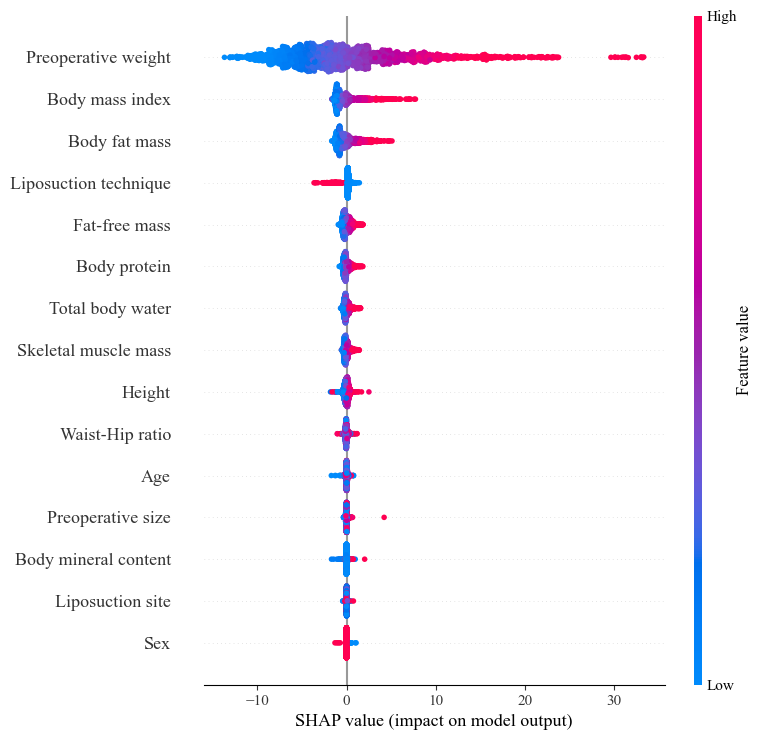

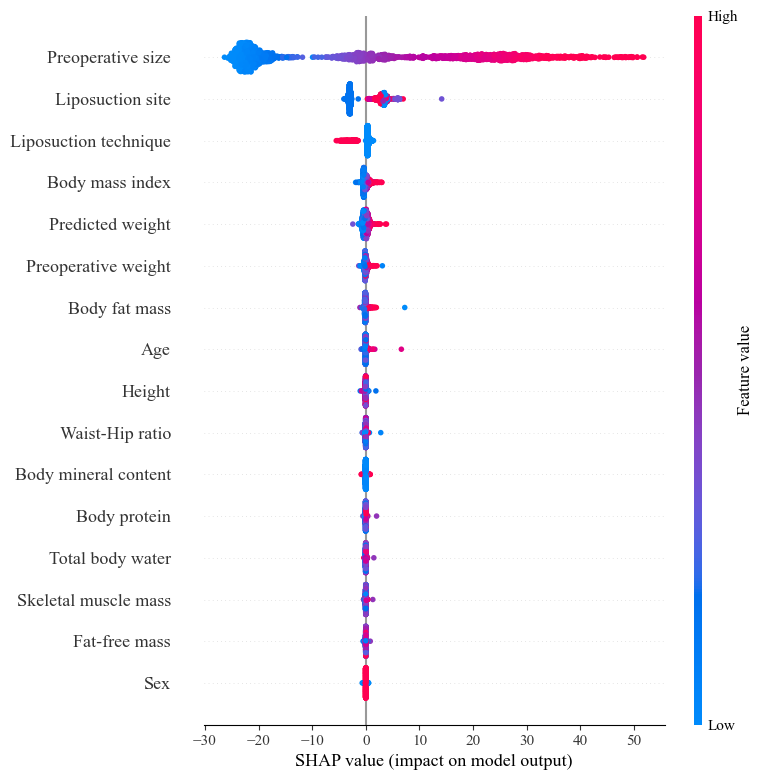

In [69]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

new_feature_names = [
    'Liposuction site', 'Sex', 'Age', 'Height', 
    'Weight', 'Size', 'TBW', 'Body protein', 'Body mineral', 'FFM',
    'SMM', 'BFM', 'WHR', 'BMI', 'Liposuction type'
]

rename_dict = {
    'Liposuction site': 'Liposuction site',
    'Sex': 'Sex',
    'Age': 'Age',
    'Height': 'Height',
    'Weight': 'Preoperative weight',
    'Size': 'Preoperative size',
    'TBW': 'Total body water',
    'Body protein': 'Body protein',
    'Body mineral': 'Body mineral content',
    'FFM': 'Fat-free mass',
    'SMM': 'Skeletal muscle mass',
    'BFM': 'Body fat mass',
    'WHR': 'Waist-Hip ratio',
    'BMI': 'Body mass index',
    'Liposuction type': 'Liposuction technique'
}

renamed_features = [rename_dict.get(feat, feat) for feat in new_feature_names]
feature_names_augmented = renamed_features + ["Predicted weight"]

# ---------------------------
# SHAP for 1st model (predicting weight)
# ---------------------------
explainer_weight = shap.Explainer(chained_et.estimators_[0])
shap_values_weight = explainer_weight(test_x)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_weight,
    test_x,
    feature_names=renamed_features,
    title="SHAP Summary - Postoperative weight (Step 1)",
    show=False
)
plt.tight_layout()
plt.savefig('shap_et_weight_step1.png', dpi=600)
plt.show()

# ---------------------------
# SHAP for 2nd model (predicting size from original + predicted weight)
# ---------------------------
predicted_weight= chained_et.estimators_[0].predict(test_x)
test_x_augmented = np.column_stack([test_x, predicted_weight])

explainer_size= shap.Explainer(chained_et.estimators_[1])
shap_values_size = explainer_size(test_x_augmented)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_size,
    test_x_augmented,
    feature_names=feature_names_augmented,
    title="SHAP Summary - Postoperative size (Step 2)",
    show=False
)
plt.tight_layout()
plt.savefig('shap_et_size_step2.png', dpi=600)
plt.show()

Bland–Altman Plot 

In [70]:
test_x

,Liposuction site,Sex,Age,Height,Weight,Size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,BMI,Liposuction type
0,2,2,-0.847783,-1.836248,-1.121276,-1.179250,-1.552911,-1.557999,-0.353972,-1.560330,-1.533385,-0.530772,0.220166,-0.597114,1
1,6,2,1.946920,0.020560,-0.540228,0.657766,0.182356,0.120738,-0.269017,0.153665,0.079844,-0.917862,0.057798,-0.607452,0
2,1,2,0.782461,0.577603,0.008775,0.479865,0.002433,-0.011149,-0.015194,0.006534,-0.011367,0.006369,0.079728,-0.220699,0
3,2,2,-0.149107,-0.722163,-0.488193,-1.063228,-0.829883,-0.762807,-0.305427,-0.818188,-0.829430,-0.130780,-1.078774,-0.258524,0
4,1,2,-0.498445,-0.722163,-0.184661,0.967158,-0.034552,0.032384,-0.270366,-0.023035,-0.008150,-0.259810,-0.266937,0.105912,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2337,1,2,0.666015,-0.722163,0.379043,1.392572,-0.227360,-0.144325,-0.300033,-0.235076,-0.184139,0.733720,1.032004,0.777921,1
2338,7,2,-0.032661,0.948964,0.379043,0.116329,0.688476,0.562511,-0.225866,0.666097,0.578478,0.075668,-0.104569,0.046465,0
2339,2,2,-0.149107,-1.093525,-0.245367,-0.947206,-0.612975,-0.586098,-0.304078,-0.623817,-0.594779,0.088571,-0.266937,0.193790,0
2340,2,2,-0.847783,0.020560,0.734611,-0.792510,-0.444268,-0.586098,-0.289245,-0.464786,-0.536116,1.430482,0.544901,0.839953,0


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [77]:
# === weight 예측 ===
weight_true = test_y.iloc[:, 0].values  # 첫 번째 타깃 (weight)
weight_pred = chained_et.estimators_[0].predict(test_x)

mean_weight = (weight_true + weight_pred) / 2
diff_weight = weight_true - weight_pred

mean_diff_weight = np.mean(diff_weight)
std_diff_weight = np.std(diff_weight)
loa_upper_weight = mean_diff_weight + 1.96 * std_diff_weight
loa_lower_weight = mean_diff_weight - 1.96 * std_diff_weight

# === size 예측 ===
weight_pred = chained_et.estimators_[0].predict(test_x)
test_x_augmented = np.column_stack([test_x, weight_pred])

size_true = test_y.iloc[:, 1].values  # 두 번째 타깃 (size)
size_pred = chained_et.estimators_[1].predict(test_x_augmented)

mean_size = (size_true + size_pred) / 2
diff_size = size_true - size_pred

mean_diff_size = np.mean(diff_size)
std_diff_size= np.std(diff_size)
loa_upper_size = mean_diff_size + 1.96 * std_diff_size
loa_lower_size = mean_diff_size - 1.96 * std_diff_size


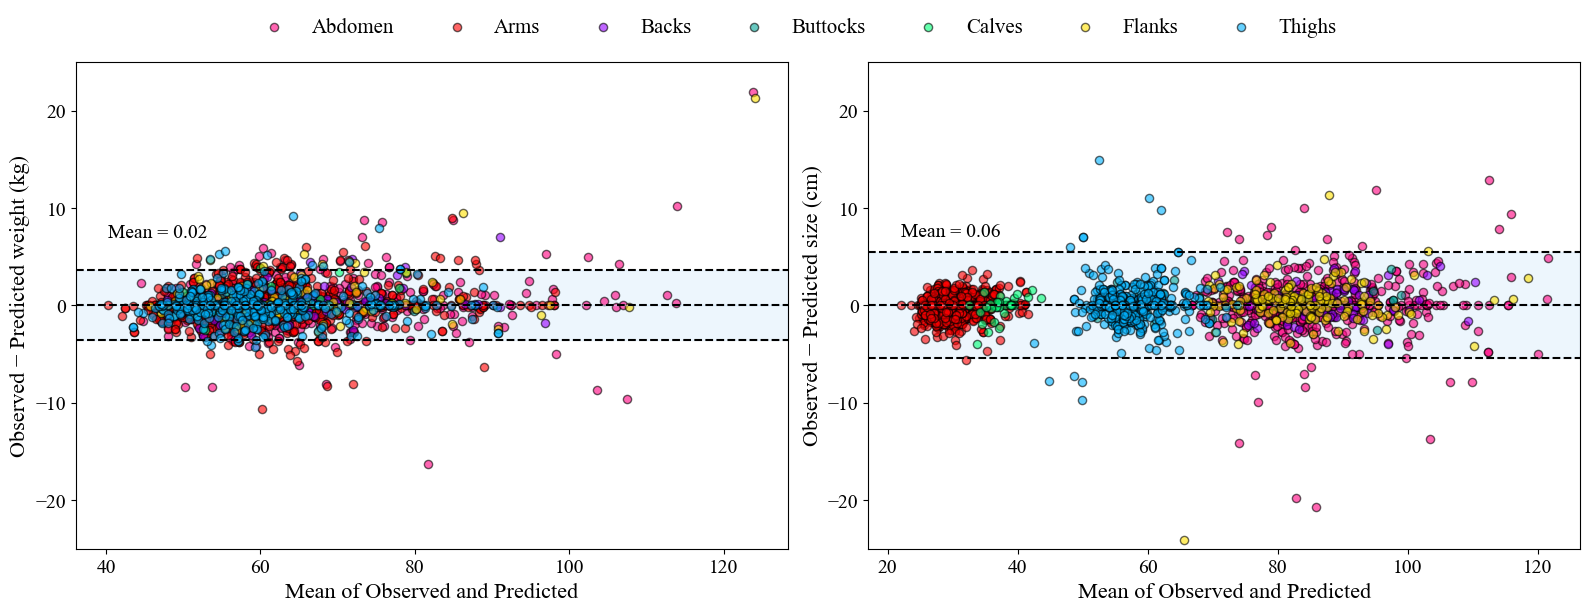

In [102]:
# body code
body_code_labels = {
    1: 'Abdomen',
    2: 'Arms',
    3: 'Backs',
    4: 'Buttocks',
    5: 'Calves',
    6: 'Flanks',
    7: 'Thighs'
}
color_dict = {
    1: "#FF0080", 
    2: "#ff0000",  
    3: "#9500ffff", 
    4: "#03a497", 
    5: "#00FF77",  
    6: "#FFE100", 
    7: "#00b3ff"  
}

fill_color = {
    'mean': "#C6E2F9", 
    'sd': "#C6E2F9"   
}

site = test_x['Liposuction site'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_bland_altman(ax, mean_vals, diff_vals, mean_diff, loa_upper, loa_lower, ylabel):
    ax.axhspan(loa_lower, loa_upper, color=fill_color['sd'], alpha=0.3, zorder=0)
    ax.axhspan(mean_diff - 0.01, mean_diff + 0.01, color=fill_color['mean'], alpha=0.5, zorder=1)

    # scatter
    for code, label in body_code_labels.items():
        idx = site == code
        ax.scatter(mean_vals[idx], diff_vals[idx], label=label,
                   color=color_dict[code], alpha=0.6, edgecolors='black', s=35, zorder=0.2)

    # line
    ax.axhline(mean_diff, color='black', linestyle='--', zorder=1)
    ax.axhline(loa_upper, color='black', linestyle='--', zorder=1)
    ax.axhline(loa_lower, color='black', linestyle='--', zorder=1)

    # text
    ax.text(mean_vals.min(), mean_diff + 7, f"Mean = {mean_diff:.2f}", color='black', fontsize=14)


    ax.set_xlabel('Mean of Observed and Predicted', fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_ylim(-25, 25)
    ax.grid(False)

# === Weight Plot ===
plot_bland_altman(
    axes[0], mean_weight, diff_weight,
    mean_diff_weight, loa_upper_weight, loa_lower_weight,
    ylabel='Observed − Predicted weight (kg)'
)

# === Size Plot ===
plot_bland_altman(
    axes[1], mean_size, diff_size,
    mean_diff_size, loa_upper_size, loa_lower_size,
    ylabel='Observed − Predicted size (cm)'
)

# legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=7, frameon=False, fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# save
save_path = r"/Users/selina/Desktop/365mc_re/0.code/3_analysis/figure/bland_altman_by_site_final.png"
plt.savefig(save_path, dpi=600)
plt.show()